# 05 · Using dataset A — external validation of the B model

**Owner:** Jaime · **Status:** sandbox · **Reading order:** after `03`–`04` · **Loader:** [`datasets.py`](datasets.py)

> **Question.** A (100 subj, task-only) gave a near-zero result trained and tested on itself
> (notebook `04` §1: reconfiguration fingerprint → `acc_2bk`, r ≈ −0.015). Is A useless here, or is that
> null just a bad *design*?

**This notebook:**
- Puts both datasets on the shared loader (`datasets.py`) and rebuilds the A/B subject overlap that
  bounds any leakage-free design (notebook `03` §6).
- Compares **four ways to use A** for the same experiment.
- **Recommendation:** A is a leakage-free **external-validation set for the B model** (its highest-value
  use); training on A alone is underpowered and should not be headlined.

*Method = notebook `04`* (per-condition Pearson FC → `2bk−0bk` → 78-dim 12-network fingerprint →
RidgeCV). Only the **train/test design** changes.

## 0 · Provenance

- NMA-curated subset of the **Human Connectome Project** (HCP); use requires accepting the HCP Data Use Terms.
- Parcellation: **Glasser 360** cortical (Glasser et al. 2016); **12-network** Cole-Anticevic partition (Ji et al. 2019).
- Target: **2-back accuracy** (`acc_2bk`), the only one common to both datasets (A ships no `d′`, see §1).
- **No subject identifiers printed anywhere — counts only.**

## Setup

In [1]:
# --- Setup: shared A/B layer + data dir (same pattern as notebooks 03/04) ---
%matplotlib inline
from pathlib import Path
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

cwd = Path.cwd().resolve()
JAIME = cwd if (cwd / "datasets.py").exists() else cwd / "sandbox" / "jaime"
ROOT = JAIME.parents[1]
sys.path.insert(0, str(JAIME))
import datasets as ds, preprocessing as pp, evaluation as ev

DATA   = Path(os.environ.get("GAMMAS_DATA_DIR", ROOT / "data"))
A, B   = ds.spec_a(DATA), ds.spec_b(DATA)
N_PERM = int(os.environ.get("GAMMAS_NPERM", "1000"))
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
print(A.name, "|", B.name)

Finalist A (100 subj, task-only) | Finalist B (339 subj, +resting-state)


In [2]:
# ----- The reconfiguration -> prediction pipeline (identical to notebook 04, condensed) -----
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

def connect_dots(brain_waves):
    "FC matrix = Pearson correlation across ROIs."
    return np.corrcoef(brain_waves)

def get_brain_profile(brain_shift, network_names, societies):
    "78-dim 12-network fingerprint: within/between-network means of an ROIxROI matrix."
    fingerprint = []
    for i, group_a in enumerate(societies):
        idx_a = np.where(network_names == group_a)[0]
        for group_b in societies[i:]:
            idx_b = np.where(network_names == group_b)[0]
            if len(idx_a) == 0 or len(idx_b) == 0:
                fingerprint.append(0.0); continue
            if group_a == group_b:
                sub = brain_shift[np.ix_(idx_a, idx_a)]; n = sub.shape[0]
                val = sub[np.triu_indices(n, k=1)].mean() if n > 1 else 0.0
            else:
                val = brain_shift[np.ix_(idx_a, idx_b)].mean()
            fingerprint.append(val)
    return fingerprint

def condition_signals(spec, subject, level, delay=4.0):
    "BOLD restricted to one load level, both runs concatenated (delay = HRF shift in frames)."
    conds = ds.COND_0BACK if level == "0back" else ds.COND_2BACK
    mats = []
    for run in (0, 1):
        ts = ds.load_timeseries(spec, subject, run)
        if spec.kind == "A":
            ev_dir = spec.task_dir/"subjects"/subject/"WM"/f"tfMRI_WM_{ds.RUN_LABELS['A'][run]}"/"EVs"
        else:
            ev_dir = spec.task_dir/"subjects"/subject/"EVs"/f"tfMRI_WM_{ds.RUN_LABELS['B'][run]}"
        frames = []
        for cond in conds:
            for onset, duration, _ in np.loadtxt(ev_dir/f"{cond}.txt", ndmin=2):
                start = int(np.floor((onset + delay) / ds.TR))
                frames.append(np.arange(start, start + int(np.ceil(duration / ds.TR))))
        frames = np.unique(np.concatenate(frames)); frames = frames[frames < ts.shape[1]]
        mats.append(ts[:, frames])
    return np.concatenate(mats, axis=1)

_FEAT = {}
def reconfig_fingerprints(spec):
    "Per-subject 2bk-0bk reconfiguration fingerprint (n x 78); cached per dataset."
    if spec.kind in _FEAT:
        return _FEAT[spec.kind]
    net = np.load(spec.task_dir / "regions.npy").T[1]
    societies = np.unique(net)
    subjects = ds.load_subjects(spec)
    fps = [get_brain_profile(connect_dots(condition_signals(spec, s, "2back"))
                             - connect_dots(condition_signals(spec, s, "0back")), net, societies)
           for s in subjects]
    _FEAT[spec.kind] = (subjects, np.array(fps), net)
    return _FEAT[spec.kind]

def target_acc(spec, subjects):
    "2-back accuracy for the given subjects (shared target A & B)."
    return pp.behaviour_table(spec).set_index("subject").loc[subjects, "acc_2bk"].to_numpy(float)

crystal_ball = lambda: RidgeCV(alphas=np.logspace(-3, 5, 100))

def cv_predict(X, y, seed=42):
    "5-fold subject-level CV; scaler fit on train only (no leakage)."
    cv = KFold(n_splits=5, shuffle=True, random_state=seed)
    pred = np.zeros_like(y, dtype=float)
    for tr, te in cv.split(X):
        sc = StandardScaler().fit(X[tr])
        pred[te] = crystal_ball().fit(sc.transform(X[tr]), y[tr]).predict(sc.transform(X[te]))
    return pred

def external_predict(Xtr, ytr, Xte):
    "Train on one cohort, predict another. Scaler fit on train only."
    sc = StandardScaler().fit(Xtr)
    return crystal_ball().fit(sc.transform(Xtr), ytr).predict(sc.transform(Xte))

## 1 · The question — dataset A and its particularities

Three features of A shape what it can do here (side-by-side QC below, via `evaluation.validate_dataset`):

- **No `d′`.** A ships no usable false-alarm rate (its `Stats.txt` Target/Non-Target accuracies are the
  documented HCP WM bug), so signal-detection `d′` is B-only. **`acc_2bk` is the only target common to both
  datasets** — every cross-dataset design below uses it.
- **No resting-state.** A is task-only (0 rest runs vs 4 in B); irrelevant to this task-based experiment,
  a limit only for future intrinsic-organization extensions.
- **100 subjects.** With a 78-dimensional fingerprint, `p ≈ n` — the regime where within-A CV is unstable
  (§3).

In [3]:
qc = pd.DataFrame({"A": ev.validate_dataset(A), "B": ev.validate_dataset(B)})
qc.loc[["dataset", "n_subjects_analytic", "acc_2bk_n", "acc_2bk_mean",
        "acc_2bk_min", "acc_2bk_max", "rest_runs_per_subject"]]

,A,B
dataset,"Finalist A (100 subj, task-only)","Finalist B (339 subj, +resting-state)"
n_subjects_analytic,100,336
acc_2bk_n,100,336
acc_2bk_mean,0.839,0.849
acc_2bk_min,0.537,0.406
acc_2bk_max,0.988,1.0
rest_runs_per_subject,0,4


## 2 · Subject overlap — the leakage constraint

- No design mixing A and B may put the **same real person** in both train and test.
- A exposes real HCP IDs; B returns integer pseudo-IDs but ships the pseudo→real map in `orig_ids.txt` (notebook `03` §6).
- Deduplicating on real IDs (analytic cohorts) gives the pools every design below draws from.
- **Counts only — no identifiers printed.**

In [4]:
ids_A  = ds.load_subjects(A)                                             # real HCP IDs (A analytic)
orig   = (B.behaviour.parents[1] / "orig_ids.txt").read_text().split()   # index -> real id (B)
subs_B = ds.load_subjects(B)                                             # B pseudo-ids (analytic)
b_real = {s: orig[int(s)] for s in subs_B}
setA, setB = set(ids_A), set(b_real.values())
shared = setA & setB
overlap = pd.Series({
    "A subjects (analytic)":  len(setA),
    "B subjects (analytic)":  len(setB),
    "shared (same person)":   len(shared),
    "A-only":                 len(setA - shared),
    "B-only":                 len(setB - shared),
    "union (unique people)":  len(setA | setB),
}, name="subjects")
print(overlap.to_string())

A subjects (analytic)    100
B subjects (analytic)    336
shared (same person)      35
A-only                    65
B-only                   301
union (unique people)    401


**Constraint.** Analytic cohorts share **35** people (A = 100, B = 336; union = 401 unique). Leakage-free pools:

- **301 B-only** subjects to train on, tested on all **100** of A.
- **65 A-only** subjects to add to B for a pooled fit.

*(Notebook `03` reported 35 shared but a union of 404: it counted all 339 B subjects, including the 3
without complete behaviour. Here we restrict to the 336 analytic.)*

## 3 · Four ways to use A

Same fingerprint (2bk−0bk), same model (RidgeCV), same target (`acc_2bk`). Only the design changes.

In [5]:
subs_A, Xa, _ = reconfig_fingerprints(A)
subs_B, Xb, _ = reconfig_fingerprints(B)
yA, yB = target_acc(A, subs_A), target_acc(B, subs_B)

b_only_idx = np.array([i for i, s in enumerate(subs_B) if b_real[s] not in setA])   # 301, disjoint from A
a_only_idx = np.array([i for i, s in enumerate(subs_A) if s not in shared])         # 65 A-only rows of Xa
print(f"Xa {Xa.shape}  Xb {Xb.shape}   |   B-only train pool {b_only_idx.size}   A-only rows {a_only_idx.size}")

Xa (100, 78)  Xb (336, 78)   |   B-only train pool 301   A-only rows 65


In [6]:
rng = np.random.default_rng(0)

# 3a - A alone: within-A 5-fold CV
r_Aalone = pearsonr(cv_predict(Xa, yA), yA)[0]

# 3b - B subsampled to n=100: power reference for A's null
r_B100 = np.array([pearsonr(cv_predict(Xb[i], yB[i]), yB[i])[0]
                   for i in (rng.choice(len(subs_B), 100, replace=False) for _ in range(30))])

# 3c - External validation: train B-only (301), test A (100). Leakage-free.
predA_ext = external_predict(Xb[b_only_idx], yB[b_only_idx], Xa)
r_ext = pearsonr(predA_ext, yA)[0]

# 3d - Pooling: A-only (65) + B (336) = 401, 5-fold CV
Xpool = np.vstack([Xa[a_only_idx], Xb]); ypool = np.concatenate([yA[a_only_idx], yB])
r_pool = np.array([pearsonr(cv_predict(Xpool, ypool, seed=s), ypool)[0] for s in range(20)])

# reference - B alone (n=336)
r_B = np.array([pearsonr(cv_predict(Xb, yB, seed=s), yB)[0] for s in range(20)])

summary = pd.DataFrame([
    ("A alone (within-A CV)",        "train A / test A",            len(yA),    r_Aalone,      np.nan),
    ("B @ n=100 (power ref)",        "train B / test B",            100,        r_B100.mean(), r_B100.std()),
    ("External val: B-only -> A",    "train B(301) / test A(100)",  len(yA),    r_ext,         np.nan),
    ("Pooling A-only + B",           "5-fold CV pooled",            len(ypool), r_pool.mean(), r_pool.std()),
    ("B alone (reference)",          "train B / test B",            len(yB),    r_B.mean(),    r_B.std()),
], columns=["design", "scheme", "n", "r", "r_std"])
summary.round(3)

,design,scheme,n,r,r_std
0,A alone (within-A CV),train A / test A,100,-0.015,NaN
1,B @ n=100 (power ref),train B / test B,100,0.078,0.146
2,External val: B-only -> A,train B(301) / test A(100),100,0.398,NaN
3,Pooling A-only + B,5-fold CV pooled,401,0.379,0.019
4,B alone (reference),train B / test B,336,0.366,0.024


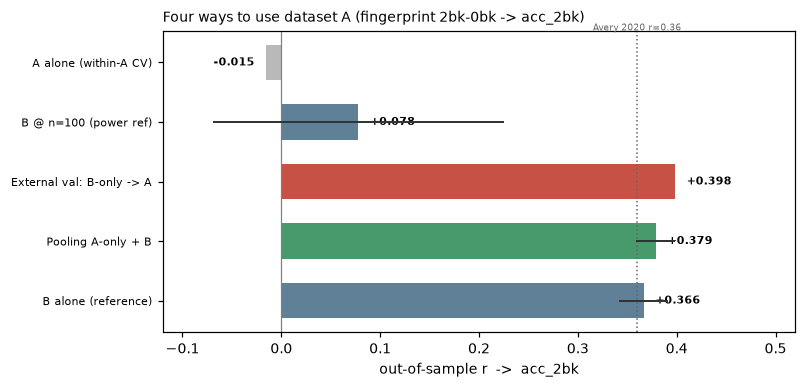

In [7]:
order = summary.iloc[::-1].reset_index(drop=True)   # first design on top
colors = {"A alone (within-A CV)": "#b0b0b0", "B @ n=100 (power ref)": "#4a6f8a",
          "External val: B-only -> A": "#c0392b", "Pooling A-only + B": "#2e8b57",
          "B alone (reference)": "#4a6f8a"}
fig, ax = plt.subplots(figsize=(7.4, 3.6))
yy = np.arange(len(order))
for j, row in order.iterrows():
    ax.barh(yy[j], row["r"], height=0.6, color=colors[row["design"]], alpha=0.88, zorder=2)
    if not np.isnan(row["r_std"]):
        ax.plot([row["r"]-row["r_std"], row["r"]+row["r_std"]], [yy[j], yy[j]], color="0.2", lw=1.3, zorder=4)
    ax.text(row["r"] + (0.012 if row["r"] >= 0 else -0.012), yy[j], f"{row['r']:+.3f}",
            va="center", ha="left" if row["r"] >= 0 else "right", fontsize=7.5, fontweight="bold")
ax.axvline(0, color="0.5", lw=0.8); ax.axvline(0.36, color="0.4", ls=":", lw=1.0)
ax.text(0.36, len(order)-0.5, "Avery 2020 r=0.36", fontsize=6, color="0.4", ha="center", va="bottom")
ax.set_yticks(yy); ax.set_yticklabels(order["design"], fontsize=7.5)
ax.set_xlim(-0.12, 0.52); ax.set_xlabel("out-of-sample r  ->  acc_2bk")
ax.set_title("Four ways to use dataset A (fingerprint 2bk-0bk -> acc_2bk)", fontsize=9, loc="left")
plt.tight_layout(); plt.show()

**Reading the four designs.**

1. **A alone fails** (r ≈ −0.015) — but this is *power*, not cohort: subsampling B to the same n = 100
   collapses to the same near-zero band (r ≈ 0.08 ± 0.15, straddling zero). A's null is what n = 100 buys
   with 78 features, not evidence that A's subjects are different.
2. **External validation is the strongest use** (train B-only → test A, r ≈ 0.40): a model that never saw
   any A subject predicts their 2-back accuracy out-of-sample, leakage-free, at a level matching — even
   slightly exceeding — B's own internal CV and the Avery 2020 benchmark. This is cross-sample
   generalization, the most convincing evidence a predictive model can offer.
3. **Pooling adds little** (r ≈ 0.38 vs 0.37 for B alone): the 65 genuinely-new A-only subjects raise n to
   401 but move the estimate within noise.
4. **B alone** stays the reference (r ≈ 0.37).

## 4 · The recommended experiment — external validation (train B → test A)

The full design 3c:
- Train the reconfiguration model on the **301 B-only** subjects.
- Predict all **100** A subjects.
- Test against a **permutation null** (permuted A labels), with a **bootstrap CI** over A subjects.

This is notebook `04`'s experiment, re-run with A as an independent held-out cohort.

In [8]:
obs_r = r_ext
perm = np.random.default_rng(0)
null_r = np.array([pearsonr(predA_ext, perm.permutation(yA))[0] for _ in range(N_PERM)])
p_ext  = ((null_r >= obs_r).sum() + 1) / (N_PERM + 1)

boot = np.random.default_rng(1)
boot_r = np.array([pearsonr(predA_ext[b], yA[b])[0]
                   for b in (boot.choice(len(yA), len(yA), replace=True) for _ in range(2000))])
ci = np.percentile(boot_r, [2.5, 97.5])

print(f"External validation  (train B-only n={b_only_idx.size}  ->  test A n={len(yA)})")
print(f"  r        = {obs_r:+.3f}")
print(f"  p (perm) = {'<0.001' if p_ext < 0.001 else format(p_ext, '.3f')}   (null max {null_r.max():+.3f})")
print(f"  95% CI   = [{ci[0]:+.3f}, {ci[1]:+.3f}]   (bootstrap over A subjects)")

External validation  (train B-only n=301  ->  test A n=100)
  r        = +0.398
  p (perm) = <0.001   (null max +0.360)
  95% CI   = [+0.250, +0.528]   (bootstrap over A subjects)


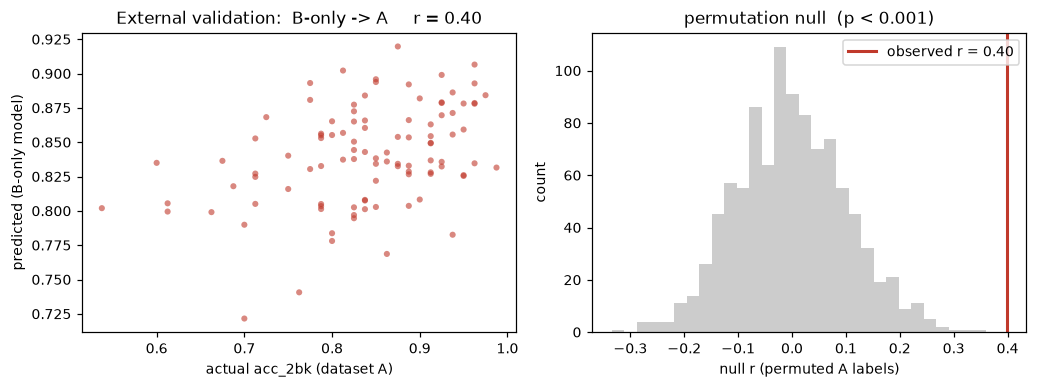

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.6))
ax1.scatter(yA, predA_ext, s=16, alpha=.6, color="#c0392b", edgecolor="none")
ax1.set(xlabel="actual acc_2bk (dataset A)", ylabel="predicted (B-only model)",
        title=f"External validation:  B-only -> A     r = {obs_r:.2f}")
ax2.hist(null_r, bins=30, color="0.8")
ax2.axvline(obs_r, color="#c0392b", lw=2, label=f"observed r = {obs_r:.2f}")
_pt = "< 0.001" if p_ext < 0.001 else ("= " + format(p_ext, ".3f"))
ax2.set(xlabel="null r (permuted A labels)", ylabel="count", title=f"permutation null  (p {_pt})")
ax2.legend()
plt.tight_layout(); plt.show()

## 5 · Limitations & conclusion

- **`acc_2bk` only.** A has no `d′`, so external validation is on accuracy; the `d′` analysis stays B-only (notebook `04` §5).
- **Sibling cohorts, not a new domain.** A-only and B are both HCP young-adult subjects, same scanner and parcellation. This is cross-*sample* generalization (independent people), not cross-*domain* (new site, clinical). Real but bounded.
- **Kinship not modelled.** The curated set exposes no family IDs, so neither cohort can do leave-families-out CV; a residual shared-family effect within each cohort is possible.
- **Pooling gain is small.** The 65 A-only subjects add power but do not change the estimate; worth it only if maximum clean n is wanted.

**Conclusion.**
- A is usable as a **leakage-free external-validation set for the B model** (r ≈ 0.40, p < 0.001) — its highest-value contribution; strengthens the claim that FC predicts WM in unseen subjects.
- Training on A alone is underpowered (r ≈ −0.015, a power artifact reproduced by B at n = 100) — not a standalone result.
- Pooling is a minor, optional power gain.